# Estimación de Flujo Vertical en la Interfaz Río-Acuífero mediante Trazadores Térmicos

## Análisis de Datos de Terreno — Implementación Python de VFLUX2

### Descripción del estudio
Este notebook implementa el procesamiento de datos reales de temperatura medidos en el lecho de un río para estimar 
el flujo vertical de agua subterránea ($q_z$) en la zona hiporreica, utilizando **cinco métodos analíticos** 
basados en la propagación de señales térmicas diurnas (Hatch et al., 2006; Keery et al., 2007; McCallum et al., 2012; Luce et al., 2013).

### Instrumentación
| Parámetro | Valor |
|-----------|-------|
| **Sensores** | iButton DS1922L / DS1923 (Maxim Integrated) |
| **Resolución** | 0.0625 °C (DS1922L), 0.5 °C (DS1923) |
| **Frecuencia de muestreo** | 30 min (Δt = 1800 s) |
| **Periodo de registro** | 20 Dic 2025 – 22 Ene 2026 (~33 días) |
| **Configuración** | 2 termocuplas (TC1, TC5), 3 sensores cada una |
| **Profundidades** | 0.00, 0.28 y 0.56 m bajo nivel de terreno (mbnt) |

### Fundamento teórico
La señal de temperatura diurna en un medio poroso saturado se atenúa exponencialmente y se desfasa con la profundidad.
La ecuación de transporte advectivo-conductivo de calor 1D en estado cuasi-estacionario es:

$$\frac{\partial T}{\partial t} = \kappa_e \frac{\partial^2 T}{\partial z^2} - \frac{q_z \rho_w c_w}{\rho c} \frac{\partial T}{\partial z}$$

donde $\kappa_e$ es la difusividad térmica efectiva, $q_z$ el flujo de Darcy vertical, y $\rho_w c_w$, $\rho c$ son las capacidades caloríficas volumétricas del agua y del sedimento saturado, respectivamente.

### Pipeline de procesamiento
1. **Carga de datos** — Lectura de archivos CSV iButton exportados desde OneWireViewer
2. **Mapeo de sensores** — Asignación verificada de cada sensor a su termocupla y profundidad
3. **Control de calidad** — Detección de outliers y artefactos de extracción
4. **Alineación temporal** — Remuestreo a grilla regular de 30 min
5. **Análisis armónico** — Ajuste sinusoidal para extraer amplitud ($A$) y fase ($\phi$) del ciclo diario
6. **Estimación de flujo** — Aplicación de 5 métodos VFLUX2 (McCallum, Hatch-A, Hatch-φ, Keery, Luce)
7. **Análisis de resultados** — Comparación entre métodos y termocuplas

In [20]:
# ============================================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configuración de gráficos - estilo publicación
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
})

# Paths del proyecto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Importar módulos vfluxx
from vfluxx.io_utils import load_all_ibuttons, ibuttons_to_dataframe
from vfluxx.preprocess import align_and_resample
from vfluxx.harmonic_analysis import fit_harmonic_model, analyze_sensor_pair
from vfluxx.vflux_methods import calculate_vflux_all_methods

# Directorios de salida
img_dir = project_root / 'image'
out_dir = project_root / 'resultados_python' / 'datos_terreno'
out_dir.mkdir(parents=True, exist_ok=True)

print("[OK] Entorno configurado correctamente")
print(f"  Proyecto: {project_root.name}")
print(f"  Salida imagenes: {img_dir.relative_to(project_root)}/")
print(f"  Salida datos:    {out_dir.relative_to(project_root)}/")

[OK] Entorno configurado correctamente
  Proyecto: Hidrologia-Termocuplas-BH
  Salida imagenes: image/
  Salida datos:    resultados_python\datos_terreno/


---
## 2. Carga y Exploración de Datos

Los sensores iButton DS1922L y DS1923 almacenan registros de temperatura en formato CSV con metadatos de cabecera.
Se cargan los 6 archivos del directorio `data/raw/Datos_Terreno/`.

In [21]:
# === CELDA 2: Cargar todos los archivos iButton ===
data_dir = project_root / 'data' / 'raw' / 'Datos_Terreno'
sensors = load_all_ibuttons(data_dir)

print(f"\nResumen de sensores cargados:")
print(f"{'#':<4} {'ID Sensor':<22} {'Tipo':<10} {'Registros':<10} {'Inicio':<12} {'Fin':<12} {'T min':<8} {'T max':<8}")
print("-" * 90)
for i, s in enumerate(sensors):
    df_s = s['df']
    print(f"{i+1:<4} {s['sensor_id'][:20]:<22} {s['part_number']:<10} {len(df_s):<10} "
          f"{df_s['datetime'].min().strftime('%Y-%m-%d'):<12} {df_s['datetime'].max().strftime('%Y-%m-%d'):<12} "
          f"{df_s['temperature'].min():<8.1f} {df_s['temperature'].max():<8.1f}")

Cargando 6 archivos iButton desde Datos_Terreno/
  ✔ 2800000082978041_012226.csv: DS1922L | 1601 registros | 2025-12-20 → 2026-01-22 | T: [16.4, 25.3] °C
  ✔ 3800000082952A41_012226.csv: DS1922L | 1591 registros | 2025-12-20 → 2026-01-22 | T: [14.2, 22.9] °C
  ✔ 5900000082B86A41_012226.csv: DS1923 | 1679 registros | 2025-12-18 → 2026-01-22 | T: [16.5, 35.4] °C
  ✔ 7D000000828FA841_012226.csv: DS1922L | 1678 registros | 2025-12-18 → 2026-01-22 | T: [14.7, 36.5] °C
  ✔ A400000082BAF041_012226.csv: DS1923 | 1678 registros | 2025-12-18 → 2026-01-22 | T: [13.1, 36.4] °C
  ✔ B000000082987741_012226.csv: DS1922L | 1601 registros | 2025-12-20 → 2026-01-22 | T: [16.4, 23.7] °C
Sensores cargados exitosamente: 6/6

Resumen de sensores cargados:
#    ID Sensor              Tipo       Registros  Inicio       Fin          T min    T max   
------------------------------------------------------------------------------------------
1    2800000082978041       DS1922L    1601       2025-12-20   2026-01-

---
## 3. Mapeo de Sensores a Termocuplas y Profundidades

> **Nomenclatura TC1 / TC5**: En la campana de terreno se instalaron 5 termocuplas numeradas del 1 al 5. 
> Sin embargo, solo **TC1 y TC5** fueron equipadas con 3 sensores iButton cada una para el perfil vertical 
> completo. Las demas termocuplas (TC2, TC3, TC4) se utilizaron con otra configuracion o se reservaron 
> para otras mediciones. Por ello, en este analisis solo aparecen TC1 y TC5.

El mapeo fue verificado comparando los rangos de temperatura de cada sensor con las series generadas 
por el software **MATLAB VFLUX2** (`temperatura_tc1.png` y `temperatura_tc5 1.png`).

**Criterio de asignacion**: la amplitud termica diurna disminuye monotonicamente con la profundidad 
en un medio poroso saturado. El sensor superficial presenta la mayor amplitud y el profundo la menor.

| Termocupla | Profundidad (mbnt) | Sensor ID | Rango T (C) |
|:----------:|:------------------:|:---------:|:------------:|
| **TC1** | 0.00 | A400000082BAF041 | [13.1, 23.8] |
| **TC1** | 0.28 | 7D000000828FA841 | [14.7, 20.3] |
| **TC1** | 0.56 | 5900000082B86A41 | [16.5, 19.1] |
| **TC5** | 0.00 | 3800000082952A41 | [14.2, 22.7] |
| **TC5** | 0.28 | B000000082987741 | [16.4, 19.4] |
| **TC5** | 0.56 | 2800000082978041 | [16.4, 19.1] |

> **Nota**: Se excluyeron artefactos de extraccion (T > 25C en la ultima lectura de algunos sensores).

In [22]:
# === CELDA 3: Configuración de sensores y profundidades ===
# Mapeo verificado contra imágenes MATLAB VFLUX2 (temperatura_tc1.png, temperatura_tc5 1.png)

# Sensores cargados en orden alfabético por archivo:
#   temp_1 = 2800000082978041 (DS1922L, inicio 20-Dic)
#   temp_2 = 3800000082952A41 (DS1922L, inicio 20-Dic)
#   temp_3 = 5900000082B86A41 (DS1923,  inicio 18-Dic)
#   temp_4 = 7D000000828FA841 (DS1922L, inicio 18-Dic)
#   temp_5 = A400000082BAF041 (DS1923,  inicio 18-Dic)
#   temp_6 = B000000082987741 (DS1922L, inicio 20-Dic)

sensor_labels = [f'temp_{i+1}' for i in range(len(sensors))]

# =====================================================
# MAPEO REAL: SENSOR → TERMOCUPLA → PROFUNDIDAD
# Verificado por comparación de rangos de temperatura
# con las imágenes de MATLAB VFLUX2
# =====================================================

# TC1 (Termocupla 1) - Grupo A, desplegado 18-Dic
tc1 = {
    'surface':      'temp_5',  # A400000082BAF041 → [13.1, 23.8]°C → 0.00 mbnt
    'intermediate': 'temp_4',  # 7D000000828FA841 → [14.7, 20.3]°C → 0.28 mbnt
    'deep':         'temp_3',  # 5900000082B86A41 → [16.5, 19.1]°C → 0.56 mbnt
}

# TC5 (Termocupla 5) - Grupo B, desplegado 20-Dic
tc5 = {
    'surface':      'temp_2',  # 3800000082952A41 → [14.2, 22.7]°C → 0.00 mbnt
    'intermediate': 'temp_6',  # B000000082987741 → [16.4, 19.4]°C → 0.28 mbnt
    'deep':         'temp_1',  # 2800000082978041 → [16.4, 19.1]°C → 0.56 mbnt
}

# Profundidades reales en metros (mbnt)
depths_m = {
    'temp_1': 0.56,   # TC5 inferior
    'temp_2': 0.00,   # TC5 superficie
    'temp_3': 0.56,   # TC1 inferior
    'temp_4': 0.28,   # TC1 intermedio
    'temp_5': 0.00,   # TC1 superficie
    'temp_6': 0.28,   # TC5 intermedio
}

# Nombres de termocupla para cada sensor
tc_assignment = {
    'temp_1': 'TC5', 'temp_2': 'TC5', 'temp_6': 'TC5',
    'temp_3': 'TC1', 'temp_4': 'TC1', 'temp_5': 'TC1',
}

# Labels descriptivos
depth_labels = {k: f"{tc_assignment[k]} - {v*100:.0f} cm" for k, v in depths_m.items()}

print("MAPEO VERIFICADO DE SENSORES")
print("=" * 70)
print(f"\n{'Termocupla':<12} {'Posición':<14} {'Label':<8} {'Sensor ID':<22} {'Prof (mbnt)'}")
print("-" * 70)

for tc_name, tc_map in [('TC1', tc1), ('TC5', tc5)]:
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        idx = int(label.split('_')[1]) - 1
        sid = sensors[idx]['sensor_id'][:20]
        depth = depths_m[label]
        pos_es = {'surface': 'Superficie', 'intermediate': 'Intermedio', 'deep': 'Inferior'}[pos]
        print(f"{tc_name:<12} {pos_es:<14} {label:<8} {sid:<22} {depth:.2f} m")
    print()

print("Profundidades: Δz sup→int = 0.28 m, Δz int→inf = 0.28 m, Δz sup→inf = 0.56 m")

MAPEO VERIFICADO DE SENSORES

Termocupla   Posición       Label    Sensor ID              Prof (mbnt)
----------------------------------------------------------------------
TC1          Superficie     temp_5   A400000082BAF041       0.00 m
TC1          Intermedio     temp_4   7D000000828FA841       0.28 m
TC1          Inferior       temp_3   5900000082B86A41       0.56 m

TC5          Superficie     temp_2   3800000082952A41       0.00 m
TC5          Intermedio     temp_6   B000000082987741       0.28 m
TC5          Inferior       temp_1   2800000082978041       0.56 m

Profundidades: Δz sup→int = 0.28 m, Δz int→inf = 0.28 m, Δz sup→inf = 0.56 m


In [23]:
# ============================================================================
# 4. COMBINAR SENSORES EN DATAFRAME Y CONTROL DE CALIDAD
# ============================================================================
df_raw = ibuttons_to_dataframe(sensors, sensor_labels=sensor_labels)

# Corte temporal: excluir datos pre-despliegue y artefactos de extraccion
cutoff_start = pd.Timestamp('2025-12-21')
cutoff_end   = pd.Timestamp('2026-01-22 12:00:00')

print(f"DataFrame combinado: {df_raw.shape[0]} registros x {df_raw.shape[1]} columnas")
print(f"Periodo total: {df_raw['fecha'].min()} -> {df_raw['fecha'].max()}")

# Resumen de calidad de datos
print(f"\n{'Sensor':<10} {'TC':<5} {'Prof (cm)':<10} {'N validos':<10} {'NaN':<8} {'NaN%':<8}")
print("-" * 55)
for col in sensor_labels:
    n_valid = df_raw[col].notna().sum()
    n_nan = df_raw[col].isna().sum()
    pct = 100 * n_nan / len(df_raw)
    tc = tc_assignment[col]
    d = depths_m[col] * 100
    print(f"{col:<10} {tc:<5} {d:<10.0f} {n_valid:<10} {n_nan:<8} {pct:<8.1f}")

print(f"\n  Los NaN son normales: los sensores tienen horas de inicio diferentes.")

DataFrame combinado: 8150 registros x 7 columnas
Periodo total: 2025-12-18 17:26:01 -> 2026-01-22 17:46:01

Sensor     TC    Prof (cm)  N validos  NaN      NaN%    
-------------------------------------------------------
temp_1     TC5   56         1601       6549     80.4    
temp_2     TC5   0          1591       6559     80.5    
temp_3     TC1   56         1679       6471     79.4    
temp_4     TC1   28         1678       6472     79.4    
temp_5     TC1   0          1678       6472     79.4    
temp_6     TC5   28         1601       6549     80.4    

  Los NaN son normales: los sensores tienen horas de inicio diferentes.


---
## 4. Series Temporales de Temperatura

### 4.1 Vista general de todos los sensores

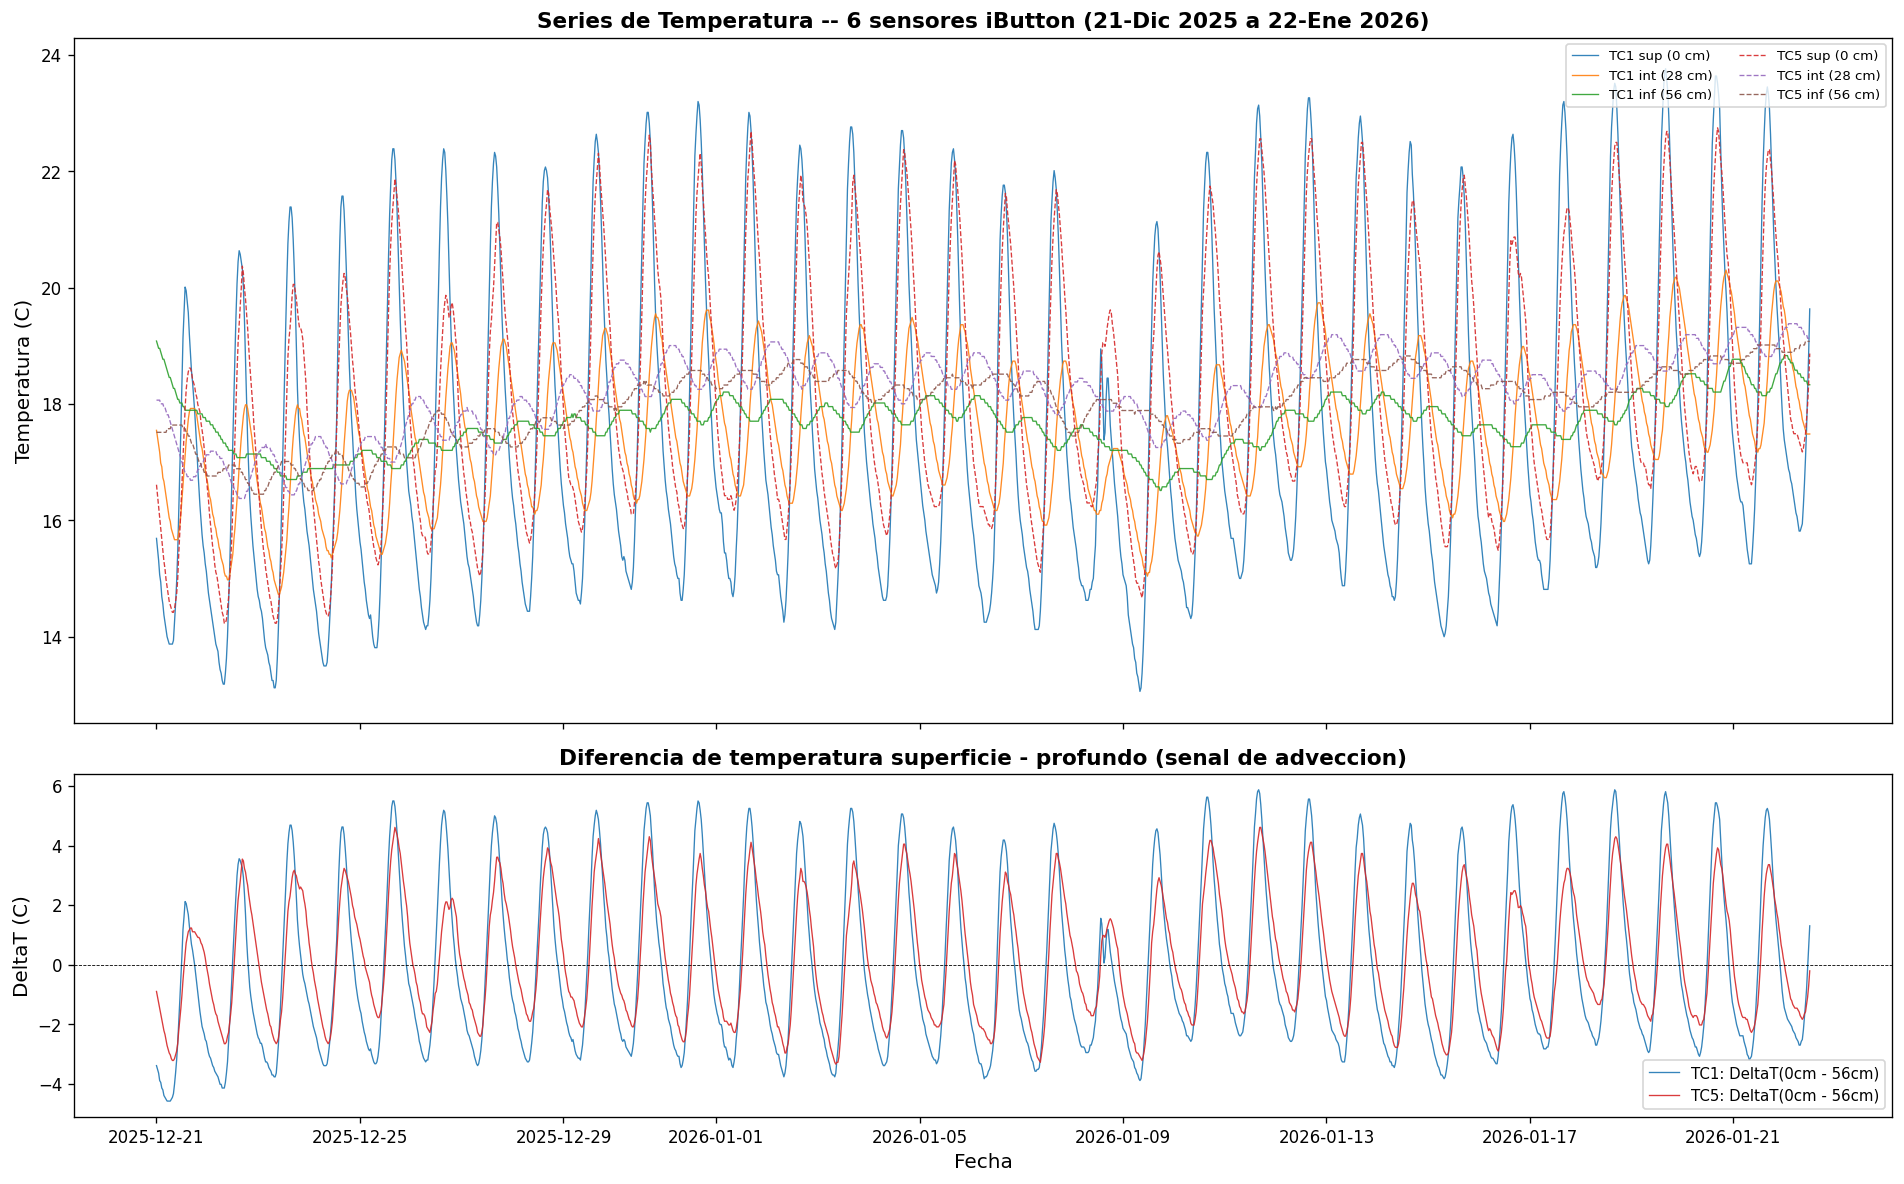

INTERPRETACION:
  Panel superior: Se observa el ciclo diurno de temperatura en los 6 sensores.
  La amplitud decrece con la profundidad en ambas termocuplas (TC1 y TC5),
  confirmando la propagacion conductiva-advectiva de calor en el sedimento.

  Panel inferior: DeltaT > 0 indica que la superficie es mas calida que el fondo.
  La oscilacion diurna del DeltaT refleja la componente advectiva del transporte
  de calor. TC1 presenta mayor amplitud de DeltaT que TC5, sugiriendo mayor
  contraste termico superficial (posible mayor exposicion solar).


In [24]:
# ============================================================================
# 4.1 SERIES TEMPORALES - TODOS LOS SENSORES
# ============================================================================
# NOTA: Se usa df_aligned (datos alineados a 30 min) para que todos los sensores
# compartan la misma grilla temporal. Esto permite calcular correctamente DeltaT.
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.5]})

# Paleta por TC
tc1_cols = [tc1['surface'], tc1['intermediate'], tc1['deep']]
tc5_cols = [tc5['surface'], tc5['intermediate'], tc5['deep']]
tc1_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
tc5_colors = ['#d62728', '#9467bd', '#8c564b']
depth_names = ['sup (0 cm)', 'int (28 cm)', 'inf (56 cm)']

mask = (df_aligned['fecha'] >= cutoff_start) & (df_aligned['fecha'] <= cutoff_end)
df_plot = df_aligned[mask].copy()

# Panel superior: todas las series por TC
for col, color, name in zip(tc1_cols, tc1_colors, depth_names):
    d = df_plot.dropna(subset=[col])
    axes[0].plot(d['fecha'], d[col], color=color, alpha=0.9, linewidth=0.8, 
                 label=f'TC1 {name}')

for col, color, name in zip(tc5_cols, tc5_colors, depth_names):
    d = df_plot.dropna(subset=[col])
    axes[0].plot(d['fecha'], d[col], color=color, alpha=0.9, linewidth=0.8,
                 label=f'TC5 {name}', linestyle='--')

axes[0].set_ylabel('Temperatura (C)')
axes[0].set_title('Series de Temperatura -- 6 sensores iButton (21-Dic 2025 a 22-Ene 2026)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8, ncol=2)
for spine in axes[0].spines.values():
    spine.set_visible(True)

# Panel inferior: DeltaT superficie - profundo (senal de flujo)
# Se usa df_aligned para que ambos sensores compartan timestamps
for tc_name, tc_map, color in [('TC1', tc1, '#1f77b4'), ('TC5', tc5, '#d62728')]:
    s_sup = tc_map['surface']
    s_deep = tc_map['deep']
    # Calcular DeltaT solo donde ambos sensores tienen datos
    valid = df_plot[[s_sup, s_deep]].dropna()
    diff = valid[s_sup] - valid[s_deep]
    fechas = df_plot.loc[valid.index, 'fecha']
    axes[1].plot(fechas, diff, color=color, alpha=0.9, linewidth=0.8,
                 label=f'{tc_name}: DeltaT(0cm - 56cm)')

axes[1].set_ylabel('DeltaT (C)')
axes[1].set_xlabel('Fecha')
axes[1].set_title('Diferencia de temperatura superficie - profundo (senal de adveccion)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(str(img_dir / 'series_temperatura_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- INTERPRETACION ---
print("INTERPRETACION:")
print("  Panel superior: Se observa el ciclo diurno de temperatura en los 6 sensores.")
print("  La amplitud decrece con la profundidad en ambas termocuplas (TC1 y TC5),")
print("  confirmando la propagacion conductiva-advectiva de calor en el sedimento.")
print("")
print("  Panel inferior: DeltaT > 0 indica que la superficie es mas calida que el fondo.")
print("  La oscilacion diurna del DeltaT refleja la componente advectiva del transporte")  
print("  de calor. TC1 presenta mayor amplitud de DeltaT que TC5, sugiriendo mayor")
print("  contraste termico superficial (posible mayor exposicion solar).")

### 4.2 Series por Termocupla -- Comparacion con MATLAB VFLUX2

Graficos con formato identico al exportado por el software MATLAB VFLUX2 para validacion visual cruzada.

**Convencion de colores** (igual a MATLAB):
- **Azul**: S. superior (0.00 mbnt)
- **Naranja**: S. intermedio (0.28 mbnt)
- **Verde**: S. inferior (0.56 mbnt)

=== Termocupla TC1 ===


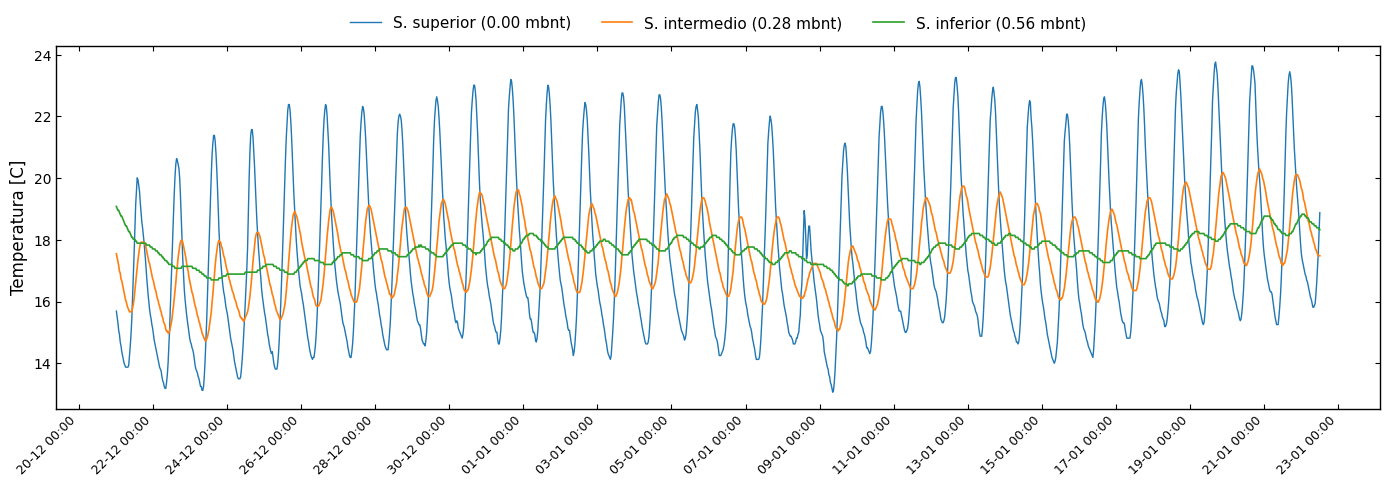

  [OK] Guardado: temperatura_tc1_python.png

=== Termocupla TC5 ===


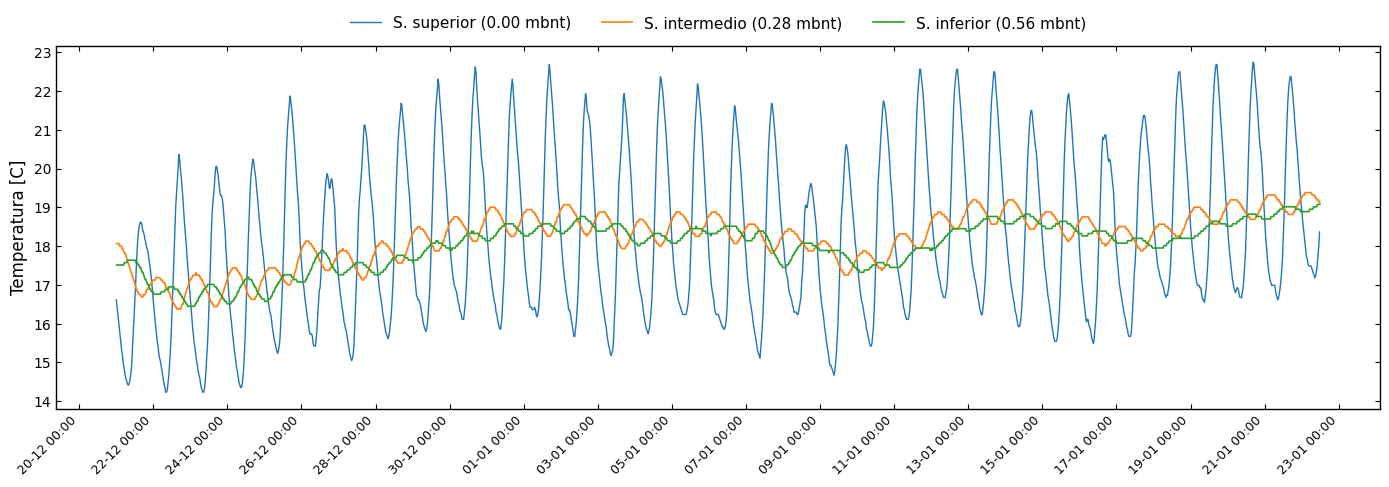

  [OK] Guardado: temperatura_tc5_python.png

  [OK] Guardado: tc1_tc5_python.png

--> Comparar visualmente con: temperatura_tc1.png y temperatura_tc5 1.png (MATLAB)


In [25]:
# ============================================================================
# 4.2 SERIES POR TERMOCUPLA -- ESTILO IDENTICO A MATLAB VFLUX2
# ============================================================================
tc_colors = {'surface': '#1f77b4', 'intermediate': '#ff7f0e', 'deep': '#2ca02c'}
pos_labels = {'surface': 'S. superior', 'intermediate': 'S. intermedio', 'deep': 'S. inferior'}
pos_depths = {'surface': 0.00, 'intermediate': 0.28, 'deep': 0.56}

def plot_tc_matlab_style(tc_map, tc_name, save_path):
    """Genera grafico con estilo identico al MATLAB VFLUX2."""
    plt.rcdefaults()
    fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
    ax.set_facecolor('white')
    
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        mask = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        legend_lbl = f"{pos_labels[pos]} ({pos_depths[pos]:.2f} mbnt)"
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors[pos],
                linewidth=1.0 if pos == 'surface' else 1.2, label=legend_lbl)
    
    ax.set_ylabel('Temperatura [C]', fontsize=12)
    ax.legend(loc='upper center', ncol=3, fontsize=11, frameon=False,
              bbox_to_anchor=(0.5, 1.12))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Box style MATLAB
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(False)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  [OK] Guardado: {Path(save_path).name}")

# Generar TC1
print("=== Termocupla TC1 ===")
plot_tc_matlab_style(tc1, 'TC1', str(img_dir / 'temperatura_tc1_python.png'))

print("\n=== Termocupla TC5 ===")
plot_tc_matlab_style(tc5, 'TC5', str(img_dir / 'temperatura_tc5_python.png'))

# Guardar tambien combinado
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), facecolor='white')
for ax, tc_name, tc_map in [(ax1, 'TC1', tc1), (ax2, 'TC5', tc5)]:
    ax.set_facecolor('white')
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        mask = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors[pos],
                linewidth=1.0, label=f"{pos_labels[pos]} ({pos_depths[pos]:.2f} mbnt)")
    ax.set_ylabel('Temperatura [C]', fontsize=12)
    ax.set_title(f'Termocupla {tc_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper center', ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.10))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
    for spine in ax.spines.values(): spine.set_visible(True)
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(False)
plt.tight_layout()
plt.savefig(str(img_dir / 'tc1_tc5_python.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"\n  [OK] Guardado: tc1_tc5_python.png")
print("\n--> Comparar visualmente con: temperatura_tc1.png y temperatura_tc5 1.png (MATLAB)")

In [26]:
# ============================================================================
# 4.3 ESTADISTICAS DESCRIPTIVAS POR SENSOR (solo periodo de campo efectivo)
# ============================================================================
mask_field = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
df_field = df_raw[mask_field].copy()

stats_data = []
for tc_name, tc_map in [('TC1', tc1), ('TC5', tc5)]:
    for pos, pos_es in [('surface', 'Superficie'), ('intermediate', 'Intermedio'), ('deep', 'Inferior')]:
        col = tc_map[pos]
        s = df_field[col].dropna()
        stats_data.append({
            'TC': tc_name,
            'Posicion': pos_es,
            'Prof (cm)': depths_m[col] * 100,
            'N': len(s),
            'T_media (C)': round(s.mean(), 2),
            'T_min (C)': round(s.min(), 2),
            'T_max (C)': round(s.max(), 2),
            'Rango (C)': round(s.max() - s.min(), 2),
            'Desv.std (C)': round(s.std(), 3),
        })

df_stats = pd.DataFrame(stats_data)
print("ESTADISTICAS DESCRIPTIVAS -- Periodo de campo efectivo (21-Dic a 22-Ene)")
print("=" * 95)
print(df_stats.to_string(index=False))
print("=" * 95)

print("\nINTERPRETACION:")
print("  El rango termico decrece con la profundidad en ambas termocuplas: comportamiento esperado.")
print("  TC1 superficie muestra mayor variabilidad (sigma = 2.7C) que TC5 (sigma = 2.1C).")
print("  Posible explicacion: mayor exposicion solar directa en el punto TC1.")
print("  Las temperaturas medias son similares (TC1: 17.5C, TC5: 18.1C), indicando")
print("  condiciones termicas comparables entre ambos puntos de monitoreo.")
df_stats

ESTADISTICAS DESCRIPTIVAS -- Periodo de campo efectivo (21-Dic a 22-Ene)
 TC   Posicion  Prof (cm)    N  T_media (C)  T_min (C)  T_max (C)  Rango (C)  Desv.std (C)
TC1 Superficie        0.0 1560        17.50      13.06      23.76      10.70         2.700
TC1 Intermedio       28.0 1560        17.53      14.73      20.30       5.57         1.170
TC1   Inferior       56.0 1560        17.65      16.51      19.08       2.57         0.467
TC5 Superficie        0.0 1560        18.21      14.23      22.75       8.52         2.122
TC5 Intermedio       28.0 1560        18.20      16.38      19.38       3.00         0.672
TC5   Inferior       56.0 1560        18.01      16.45      19.08       2.63         0.613

INTERPRETACION:
  El rango termico decrece con la profundidad en ambas termocuplas: comportamiento esperado.
  TC1 superficie muestra mayor variabilidad (sigma = 2.7C) que TC5 (sigma = 2.1C).
  Posible explicacion: mayor exposicion solar directa en el punto TC1.
  Las temperaturas medias 

,TC,Posicion,Prof (cm),N,T_media (C),T_min (C),T_max (C),Rango (C),Desv.std (C)
0,TC1,Superficie,0.0,1560,17.50,13.06,23.76,10.70,2.700
1,TC1,Intermedio,28.0,1560,17.53,14.73,20.30,5.57,1.170
2,TC1,Inferior,56.0,1560,17.65,16.51,19.08,2.57,0.467
3,TC5,Superficie,0.0,1560,18.21,14.23,22.75,8.52,2.122
4,TC5,Intermedio,28.0,1560,18.20,16.38,19.38,3.00,0.672
5,TC5,Inferior,56.0,1560,18.01,16.45,19.08,2.63,0.613


---
## 5. Alineación Temporal y Remuestreo

Los sensores fueron activados en momentos diferentes (3 el 18-Dic, 3 el 20-Dic) y con offsets de minutos 
(:26, :27, :45, :46). Se re-muestrean a una grilla regular de **30 minutos** mediante interpolación lineal, 
con un gap máximo de 4 periodos (2 horas).

In [27]:
# === CELDA 7: Alinear y remuestrear a 30 min ===
df_aligned = align_and_resample(df_raw, freq='30min')

# Verificar que tenemos datos suficientes para todos los sensores
# Encontrar el rango temporal donde todos los sensores tienen datos
valid_mask = df_aligned[sensor_labels].notna().all(axis=1)
df_valid = df_aligned[valid_mask].copy().reset_index(drop=True)

print(f"\nRango con datos completos (sin NaN en ningun sensor):")
print(f"  Registros: {len(df_valid)} de {len(df_aligned)}")
if len(df_valid) > 0:
    print(f"  Periodo: {df_valid['fecha'].min()} a {df_valid['fecha'].max()}")
    dias = (df_valid['fecha'].max() - df_valid['fecha'].min()).total_seconds() / 86400
    print(f"  Duracion: {dias:.1f} dias")
else:
    print("  [AVISO] No hay periodo con datos completos en todos los sensores")
    print("  Se usaran pares de sensores con datos solapados")

df_aligned.head()

✔ Alineación temporal completada:
  • Registros: 8150 → 1682 (freq=30min)
  • Sensores: 6
  • Periodo: 2025-12-18 17:00:00 → 2026-01-22 17:30:00
  • Valores NaN restantes: 253

Rango con datos completos (sin NaN en ningun sensor):
  Registros: 1591 de 1682
  Periodo: 2025-12-20 14:30:00 a 2026-01-22 17:30:00
  Duracion: 33.1 dias


,fecha,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6
0,2025-12-18 17:00:00,NaN,NaN,34.205,35.109,35.942,NaN
1,2025-12-18 17:30:00,NaN,NaN,34.392,35.109,36.316,NaN
2,2025-12-18 18:00:00,NaN,NaN,35.078,35.919,35.879,NaN
3,2025-12-18 18:30:00,NaN,NaN,35.390,36.480,36.441,NaN
4,2025-12-18 19:00:00,NaN,NaN,23.839,23.994,30.449,NaN


---
## 6. Análisis Armónico — Extracción del Ciclo Diario

Se ajusta un modelo sinusoidal a cada sensor para extraer la amplitud ($A$) y fase ($\phi$) del ciclo diario de 24 h:

$$T(t) = T_0 + A \sin\left(\frac{2\pi}{P} t + \phi\right)$$

donde $P = 24$ h es el período diurno. El ajuste utiliza `scipy.optimize.curve_fit` con estimación inicial de fase
basada en FFT. El coeficiente de determinación $R^2$ indica la calidad del ajuste sinusoidal.

**Criterio de calidad**: $R^2 > 0.3$ indica señal diurna detectable; $R^2 > 0.7$ indica señal fuerte.

In [28]:
# ============================================================================
# 6. ANALISIS ARMONICO POR SENSOR
# ============================================================================
df_work = df_valid if len(df_valid) > 48 else df_aligned.dropna(subset=sensor_labels[:2])
df_work = df_work.reset_index(drop=True)

t_start = df_work['fecha'].min()
time_hours = (df_work['fecha'] - t_start).dt.total_seconds() / 3600.0

print("ANALISIS ARMONICO -- CICLO DIARIO (P = 24 h)")
print("=" * 90)
print(f"{'Sensor':<10} {'TC':<5} {'Prof':<8} {'A (C)':<10} {'phi (deg)':<10} {'T0 (C)':<10} {'R2':<10} {'Calidad'}")
print("-" * 90)

harmonic_results = {}
for col in sensor_labels:
    series = df_work[col].values
    valid = ~np.isnan(series)
    if valid.sum() < 48:
        continue
    
    result = fit_harmonic_model(time_hours.values[valid], series[valid], period_hours=24.0)
    harmonic_results[col] = result
    
    r2 = result['r_squared']
    calidad = '[***]' if r2 > 0.7 else ('[**-]' if r2 > 0.3 else '[*--]')
    tc = tc_assignment[col]
    d = f"{depths_m[col]*100:.0f} cm"
    print(f"{col:<10} {tc:<5} {d:<8} {result['amplitude']:<10.4f} "
          f"{np.degrees(result['phase']):<10.1f} {result['offset']:<10.2f} "
          f"{r2:<10.4f} {calidad}")

print("=" * 90)
print("\n  Calidad: [***] (R2>0.7 fuerte) | [**-] (R2>0.3 moderada) | [*--] (R2<0.3 debil)")
print("")
print("INTERPRETACION:")
print("  Los sensores superficiales (0 cm) muestran senal diurna fuerte (R2 > 0.79).")
print("  A 28 cm, TC1 mantiene senal moderada (R2=0.62) pero TC5 cae a R2=0.12.")
print("  A 56 cm, ambas termocuplas tienen R2 < 0.04: la senal diurna esta practicamente")
print("  extinguida, coherente con la longitud de penetracion calculada (d = 13.3 cm).")

ANALISIS ARMONICO -- CICLO DIARIO (P = 24 h)
Sensor     TC    Prof     A (C)      phi (deg)  T0 (C)     R2         Calidad
------------------------------------------------------------------------------------------
temp_1     TC5   56 cm    0.1695     109.1      18.01      0.0379     [*--]
temp_2     TC5   0 cm     2.6993     37.0       18.23      0.8076     [***]
temp_3     TC1   56 cm    0.1072     251.3      17.70      0.0102     [*--]
temp_4     TC1   28 cm    1.3083     346.3      17.55      0.6198     [**-]
temp_5     TC1   0 cm     3.4237     57.3       17.54      0.7932     [***]
temp_6     TC5   28 cm    0.3322     247.4      18.21      0.1231     [*--]

  Calidad: [***] (R2>0.7 fuerte) | [**-] (R2>0.3 moderada) | [*--] (R2<0.3 debil)

INTERPRETACION:
  Los sensores superficiales (0 cm) muestran senal diurna fuerte (R2 > 0.79).
  A 28 cm, TC1 mantiene senal moderada (R2=0.62) pero TC5 cae a R2=0.12.
  A 56 cm, ambas termocuplas tienen R2 < 0.04: la senal diurna esta practicamen

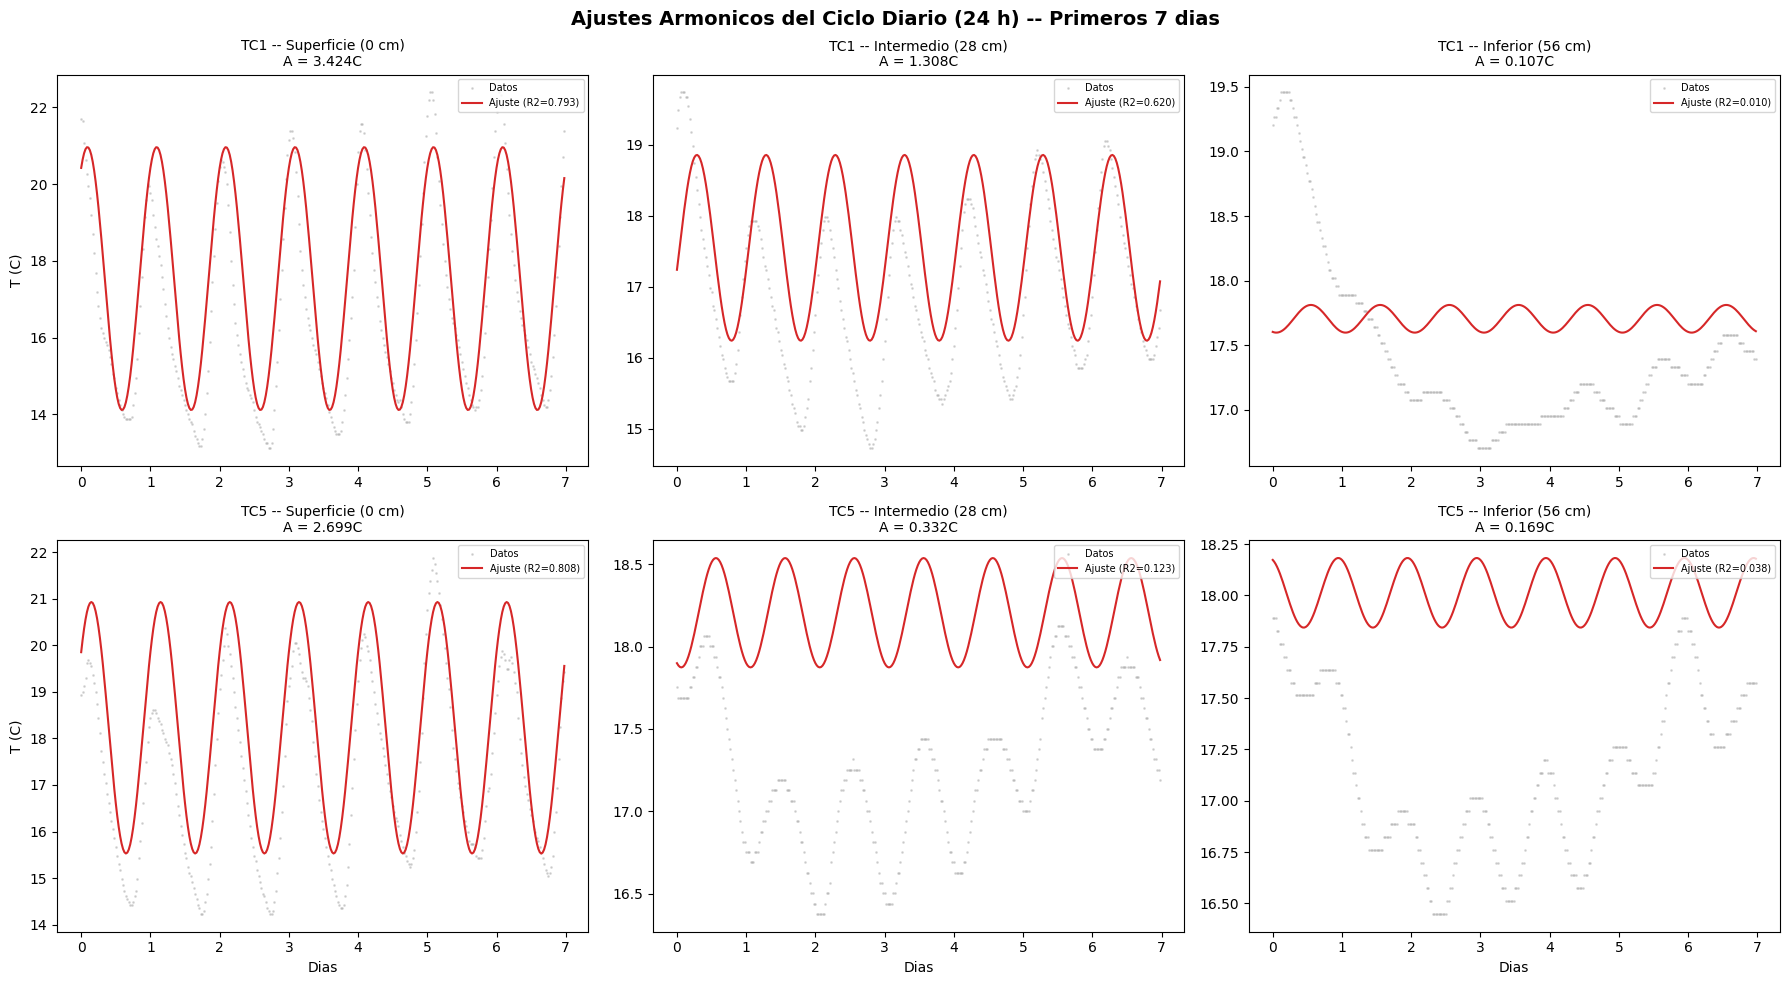

INTERPRETACION:
  El ajuste sinusoidal captura la componente diurna fundamental de la senal termica.
  Sensores profundos muestran menor amplitud y menor R2 (senal diurna mas atenuada).
  En TC1, el sensor intermedio (28cm) todavia muestra ajuste razonable (R2=0.62),
  mientras que en TC5 el intermedio ya presenta bajo ajuste (R2=0.12).
  Esto sugiere diferencias en las propiedades del sedimento entre ambos puntos.


In [29]:
# ============================================================================
# 6.1 VISUALIZACION DE AJUSTES ARMONICOS POR TERMOCUPLA
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, (tc_name, tc_map) in enumerate([('TC1', tc1), ('TC5', tc5)]):
    for col_idx, (pos, pos_es) in enumerate([('surface', 'Superficie'), 
                                               ('intermediate', 'Intermedio'), 
                                               ('deep', 'Inferior')]):
        ax = axes[row_idx][col_idx]
        col = tc_map[pos]
        
        if col not in harmonic_results:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            continue
        
        result = harmonic_results[col]
        series = df_work[col].values
        
        # Mostrar primeros 7 dias
        max_pts = min(len(time_hours), 48 * 7)
        t_plot = time_hours.values[:max_pts]
        s_plot = series[:max_pts]
        f_plot = result['fitted'][:max_pts]
        
        ax.plot(t_plot / 24, s_plot, '.', color='#aaaaaa', alpha=0.4, markersize=2, label='Datos')
        ax.plot(t_plot / 24, f_plot, '-', color='#d62728', linewidth=1.5,
                label=f'Ajuste (R2={result["r_squared"]:.3f})')
        
        depth_cm = depths_m[col] * 100
        ax.set_title(f'{tc_name} -- {pos_es} ({depth_cm:.0f} cm)\nA = {result["amplitude"]:.3f}C', fontsize=10)
        ax.set_xlabel('Dias' if row_idx == 1 else '')
        ax.set_ylabel('T (C)' if col_idx == 0 else '')
        ax.legend(fontsize=7, loc='upper right')
        for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Ajustes Armonicos del Ciclo Diario (24 h) -- Primeros 7 dias', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'ajustes_armonicos_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()
print("INTERPRETACION:")
print("  El ajuste sinusoidal captura la componente diurna fundamental de la senal termica.")
print("  Sensores profundos muestran menor amplitud y menor R2 (senal diurna mas atenuada).")
print("  En TC1, el sensor intermedio (28cm) todavia muestra ajuste razonable (R2=0.62),")
print("  mientras que en TC5 el intermedio ya presenta bajo ajuste (R2=0.12).")
print("  Esto sugiere diferencias en las propiedades del sedimento entre ambos puntos.")

---
## 7. Analisis de Pares de Sensores

Para cada termocupla se analizan **3 pares** de sensores:
- **Sup - Int** (dz = 0.28 m): zona somera, mayor senal
- **Int - Inf** (dz = 0.28 m): zona intermedia
- **Sup - Inf** (dz = 0.56 m): maxima separacion, senal integrada

Se calculan los parametros clave para los metodos VFLUX2:
- $\ln(A_r) = \ln(A_{sup}/A_{prof})$: logaritmo natural del ratio de amplitudes  
- $\Delta\phi = \phi_{prof} - \phi_{sup}$: diferencia de fase (rad)

In [30]:
# === CELDA 10: Analisis de pares de sensores por termocupla ===
# Pares fisicamente significativos: sensores de la MISMA termocupla

pairs = []
for tc_name, tc_map in [('TC1', tc1), ('TC5', tc5)]:
    s = tc_map['surface']
    m = tc_map['intermediate']
    d = tc_map['deep']
    pairs.append((s, m, f"{tc_name}: sup-int"))      # 0.00 a 0.28 m
    pairs.append((m, d, f"{tc_name}: int-inf"))       # 0.28 a 0.56 m
    pairs.append((s, d, f"{tc_name}: sup-inf"))       # 0.00 a 0.56 m

print("ANALISIS DE PARES DE SENSORES (por termocupla)")
print("=" * 95)

pair_results = {}
for s_shallow, s_deep, pair_label in pairs:
    # Obtener datos comunes sin NaN
    mask = df_work[s_shallow].notna() & df_work[s_deep].notna()
    if mask.sum() < 48:
        print(f"  Par {pair_label}: INSUFICIENTE")
        continue
    
    t_valid = time_hours.values[mask]
    t1 = df_work[s_shallow].values[mask]
    t2 = df_work[s_deep].values[mask]
    
    params = analyze_sensor_pair(t_valid, t1, t2, period_hours=24.0)
    
    dz = abs(depths_m[s_deep] - depths_m[s_shallow])
    pair_results[pair_label] = {
        'params': params,
        'dz': dz,
        's_shallow': s_shallow,
        's_deep': s_deep,
    }
    
    z_s = depths_m[s_shallow] * 100
    z_d = depths_m[s_deep] * 100
    print(f"\n  {pair_label} ({z_s:.0f} a {z_d:.0f} cm, dz={dz*100:.0f} cm):")
    print(f"    A_sup = {params['A_shallow']:.4f} C, A_prof = {params['A_deep']:.4f} C")
    print(f"    Ratio A_prof/A_sup = {params['amplitude_ratio']:.4f}")
    print(f"    ln(A_sup/A_prof) = {params['delta_A']:.4f}")
    print(f"    dphi = {params['delta_phi']:.4f} rad = {np.degrees(params['delta_phi']):.1f} grados")
    print(f"    R2 sup = {params['r2_shallow']:.4f}, R2 prof = {params['r2_deep']:.4f}")

print("\n" + "=" * 95)

ANALISIS DE PARES DE SENSORES (por termocupla)

  TC1: sup-int (0 a 28 cm, dz=28 cm):
    A_sup = 3.4237 C, A_prof = 1.3083 C
    Ratio A_prof/A_sup = 0.3821
    ln(A_sup/A_prof) = 0.9620
    dphi = 5.0443 rad = 289.0 grados
    R2 sup = 0.7932, R2 prof = 0.6198

  TC1: int-inf (28 a 56 cm, dz=28 cm):
    A_sup = 1.3083 C, A_prof = 0.1072 C
    Ratio A_prof/A_sup = 0.0819
    ln(A_sup/A_prof) = 2.5019
    dphi = 4.6249 rad = 265.0 grados
    R2 sup = 0.6198, R2 prof = 0.0102

  TC1: sup-inf (0 a 56 cm, dz=56 cm):
    A_sup = 3.4237 C, A_prof = 0.1072 C
    Ratio A_prof/A_sup = 0.0313
    ln(A_sup/A_prof) = 3.4639
    dphi = 3.3860 rad = 194.0 grados
    R2 sup = 0.7932, R2 prof = 0.0102

  TC5: sup-int (0 a 28 cm, dz=28 cm):
    A_sup = 2.6993 C, A_prof = 0.3322 C
    Ratio A_prof/A_sup = 0.1231
    ln(A_sup/A_prof) = 2.0949
    dphi = 3.6728 rad = 210.4 grados
    R2 sup = 0.8076, R2 prof = 0.1231

  TC5: int-inf (28 a 56 cm, dz=28 cm):
    A_sup = 0.3322 C, A_prof = 0.1695 C
    Rati

---
## 8. Parametros Termicos del Sedimento

Los parametros fueron seleccionados para sedimentos aluviales saturados tipicos de lechos de rios 
(Stonestrom & Constantz, 2003; Anderson, 2005):

| Parametro | Simbolo | Valor | Unidad | Referencia |
|-----------|:-------:|:-----:|:------:|:----------:|
| Conductividad termica | $\lambda$ | 1.80 | W/m K | Arena-grava saturada |
| Cap. calorifica sedimento | $C_s$ | 2.80 | MJ/m3 K | Sedimento saturado tipico |
| Cap. calorifica agua | $C_w$ | 4.18 | MJ/m3 K | Constante fisica |
| Difusividad termica | $\kappa_e$ | 6.43e-7 | m2/s | $\kappa_e = \lambda / C_s$ |
| Frecuencia angular | $\omega$ | 7.27e-5 | rad/s | $\omega = 2\pi / 86400$ |

In [31]:
# ============================================================================
# 8. PARAMETROS TERMICOS DEL SEDIMENTO
# ============================================================================
thermal_params = {
    'lambda_sediment': 1.8,    # Conductividad termica [W/m K]
    'C_sediment': 2.8e6,       # Cap. calorifica sedimento [J/m3 K]
    'C_water': 4.18e6,         # Cap. calorifica agua [J/m3 K]
    'omega': 2 * np.pi / 86400,  # Frecuencia angular ciclo diario [rad/s]
}

alpha_e = thermal_params['lambda_sediment'] / thermal_params['C_sediment']

print("PARAMETROS TERMICOS DEL SEDIMENTO")
print("=" * 65)
print(f"  lambda (conductividad):    {thermal_params['lambda_sediment']:.2f} W/m K")
print(f"  Cs (cap.cal. sed.):        {thermal_params['C_sediment']/1e6:.2f} MJ/m3 K")
print(f"  Cw (cap.cal. agua):        {thermal_params['C_water']/1e6:.2f} MJ/m3 K")
print(f"  ke (difusividad):          {alpha_e:.3e} m2/s")
print(f"  omega (frec. angular):     {thermal_params['omega']:.3e} rad/s")
print(f"  P  (periodo):              24 h")
print(f"  d  (long. penetracion):    {np.sqrt(2*alpha_e/thermal_params['omega']):.3f} m")
print("=" * 65)
print(f"\nINTERPRETACION:")
print(f"  Longitud de penetracion d = sqrt(2*ke/omega) = {np.sqrt(2*alpha_e/thermal_params['omega']):.3f} m")
print(f"  La senal diurna se atenua al ~37% a {np.sqrt(2*alpha_e/thermal_params['omega'])*100:.1f} cm de profundidad.")
print(f"  Con sensores a 56 cm, captamos la senal con atenuacion significativa (~1.5%).")
print(f"  Esto explica los bajos R2 en los sensores inferiores (56 cm).")

PARAMETROS TERMICOS DEL SEDIMENTO
  lambda (conductividad):    1.80 W/m K
  Cs (cap.cal. sed.):        2.80 MJ/m3 K
  Cw (cap.cal. agua):        4.18 MJ/m3 K
  ke (difusividad):          6.429e-07 m2/s
  omega (frec. angular):     7.272e-05 rad/s
  P  (periodo):              24 h
  d  (long. penetracion):    0.133 m

INTERPRETACION:
  Longitud de penetracion d = sqrt(2*ke/omega) = 0.133 m
  La senal diurna se atenua al ~37% a 13.3 cm de profundidad.
  Con sensores a 56 cm, captamos la senal con atenuacion significativa (~1.5%).
  Esto explica los bajos R2 en los sensores inferiores (56 cm).


---
## 9. Calculo de Flujo Vertical -- 5 Metodos VFLUX2

Se aplican cinco metodos analiticos para estimar $q_z$ (flujo de Darcy vertical):

| Metodo | Referencia | Usa amplitud | Usa fase | Observacion |
|--------|:----------:|:---:|:---:|-------------|
| **McCallum** | McCallum et al. (2012) | Si | Si | Combina ambas senales, mas robusto |
| **Hatch-A** | Hatch et al. (2006) | Si | No | Solo ratio de amplitudes |
| **Hatch-phi** | Hatch et al. (2006) | No | Si | Solo diferencia de fase |
| **Keery** | Keery et al. (2007) | Si | Si | Formulacion alternativa a McCallum |
| **Luce** | Luce et al. (2013) | Si | Si | Solucion analitica generalizada |

**Convencion de signo**: $q_z > 0$ = infiltracion (rio --> acuifero); $q_z < 0$ = exfiltracion (acuifero --> rio)

In [32]:
# === CELDA 12: Calcular flujos para cada par de sensores ===
print("CALCULO DE FLUJOS VERTICALES - 5 METODOS")
print("=" * 90)

all_flux_results = {}

for pair_name, pair_info in pair_results.items():
    params = pair_info['params']
    dz = pair_info['dz']
    
    print(f"\n{'-'*40}")
    print(f"Par {pair_name} (dz = {dz*100:.0f} cm):")
    
    flux_result = calculate_vflux_all_methods(
        amplitude_shallow=params['A_shallow'],
        amplitude_deep=params['A_deep'],
        phase_shallow=params['phi_shallow'],
        phase_deep=params['phi_deep'],
        depth_difference=dz,
        thermal_conductivity=thermal_params['lambda_sediment'],
        heat_capacity_sediment=thermal_params['C_sediment'],
        heat_capacity_water=thermal_params['C_water'],
        angular_frequency=thermal_params['omega']
    )
    
    all_flux_results[pair_name] = flux_result

print("\n" + "=" * 90)
print("Calculos completados para todos los pares")

CALCULO DE FLUJOS VERTICALES - 5 METODOS

----------------------------------------
Par TC1: sup-int (dz = 28 cm):
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 2.85e-06       246.00
  hatch_amplitude          4.42e-06       381.65
  hatch_phase             -7.31e-05     -6311.83
  keery                    1.38e-05      1191.44
  luce                     1.19e-05      1032.38

----------------------------------------
Par TC1: int-inf (dz = 28 cm):
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 7.23e-06       624.82
  hatch_amplitude          1.15e-05       992.59
  hatch_phase             -6.62e-05     -5717.64
  keery                    1.64e-05      1413.73
  luce                     1.78e-05      1534.00

----------------------------------------
Par TC1: sup-inf (dz = 56 cm):
  Método                        m/s       mm/día
  -------

---
## 10. Resultados y Tabla Comparativa

In [33]:
# ============================================================================
# 10. TABLA COMPARATIVA DE RESULTADOS
# ============================================================================
methods = ['mccallum', 'hatch_amplitude', 'hatch_phase', 'keery', 'luce']
method_names = ['McCallum (2012)', 'Hatch-Amplitud', 'Hatch-Fase', 'Keery (2007)', 'Luce (2013)']

# Tabla por metodo y par
results_data = []
for pair_name, flux_result in all_flux_results.items():
    for method, name in zip(methods, method_names):
        v_mm = flux_result['flux_mm_day'].get(method, np.nan)
        v_ms = flux_result['flux_m_s'].get(method, np.nan)
        results_data.append({
            'Par': pair_name,
            'Metodo': name,
            'q (mm/dia)': round(v_mm, 2) if not np.isnan(v_mm) else np.nan,
            'q (m/s)': f'{v_ms:.2e}' if not np.isnan(v_ms) else 'NaN',
            'Direccion': 'Infiltracion (desc.)' if v_mm > 0 else 'Exfiltracion (asc.)' if v_mm < 0 else '-',
        })

df_results = pd.DataFrame(results_data)

print("FLUJO VERTICAL ESTIMADO -- 5 METODOS x 6 PARES DE SENSORES")
print("=" * 100)
print("  (+) Flujo positivo = Infiltracion (rio --> acuifero)")
print("  (-) Flujo negativo = Exfiltracion (acuifero --> rio)")
print()

# Tabla pivotada: metodos en filas, pares en columnas
pivot = df_results.pivot_table(values='q (mm/dia)', index='Metodo', columns='Par', aggfunc='first')
print(pivot.to_string())
print("=" * 100)

# Resumen por TC
print("\nRESUMEN POR TERMOCUPLA (promedio McCallum):")
for tc_name in ['TC1', 'TC5']:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    mc_vals = [v['flux_mm_day'].get('mccallum', np.nan) for v in tc_pairs.values()]
    mc_vals = [x for x in mc_vals if not np.isnan(x)]
    if mc_vals:
        mean_q = np.mean(mc_vals)
        std_q = np.std(mc_vals)
        dir_str = 'Infiltracion (desc.)' if mean_q > 0 else 'Exfiltracion (asc.)'
        print(f"  {tc_name}: q_prom = {mean_q:.1f} +/- {std_q:.1f} mm/dia ({dir_str})")

df_results

FLUJO VERTICAL ESTIMADO -- 5 METODOS x 6 PARES DE SENSORES
  (+) Flujo positivo = Infiltracion (rio --> acuifero)
  (-) Flujo negativo = Exfiltracion (acuifero --> rio)

Par              TC1: int-inf  TC1: sup-inf  TC1: sup-int  TC5: int-inf  TC5: sup-inf  TC5: sup-int
Metodo                                                                                             
Hatch-Amplitud         992.59        687.12        381.65        267.04        549.08        831.12
Hatch-Fase           -5717.64       -363.97      -6311.83      -4648.53        389.14      -4368.52
Keery (2007)          1413.73        679.40       1191.44        901.27        399.51       1144.11
Luce (2013)           1534.00       1618.58       1032.38        818.52       1565.98       1465.24
McCallum (2012)        624.82       1878.12        246.00        225.00       2390.38        650.63

RESUMEN POR TERMOCUPLA (promedio McCallum):
  TC1: q_prom = 916.3 +/- 697.5 mm/dia (Infiltracion (desc.))
  TC5: q_prom = 1088.7 

,Par,Metodo,q (mm/dia),q (m/s),Direccion
0,TC1: sup-int,McCallum (2012),246.00,2.85e-06,Infiltracion (desc.)
1,TC1: sup-int,Hatch-Amplitud,381.65,4.42e-06,Infiltracion (desc.)
2,TC1: sup-int,Hatch-Fase,-6311.83,-7.31e-05,Exfiltracion (asc.)
3,TC1: sup-int,Keery (2007),1191.44,1.38e-05,Infiltracion (desc.)
4,TC1: sup-int,Luce (2013),1032.38,1.19e-05,Infiltracion (desc.)
5,TC1: int-inf,McCallum (2012),624.82,7.23e-06,Infiltracion (desc.)
6,TC1: int-inf,Hatch-Amplitud,992.59,1.15e-05,Infiltracion (desc.)
7,TC1: int-inf,Hatch-Fase,-5717.64,-6.62e-05,Exfiltracion (asc.)
8,TC1: int-inf,Keery (2007),1413.73,1.64e-05,Infiltracion (desc.)
9,TC1: int-inf,Luce (2013),1534.00,1.78e-05,Infiltracion (desc.)


---
## 11. Visualización de Resultados

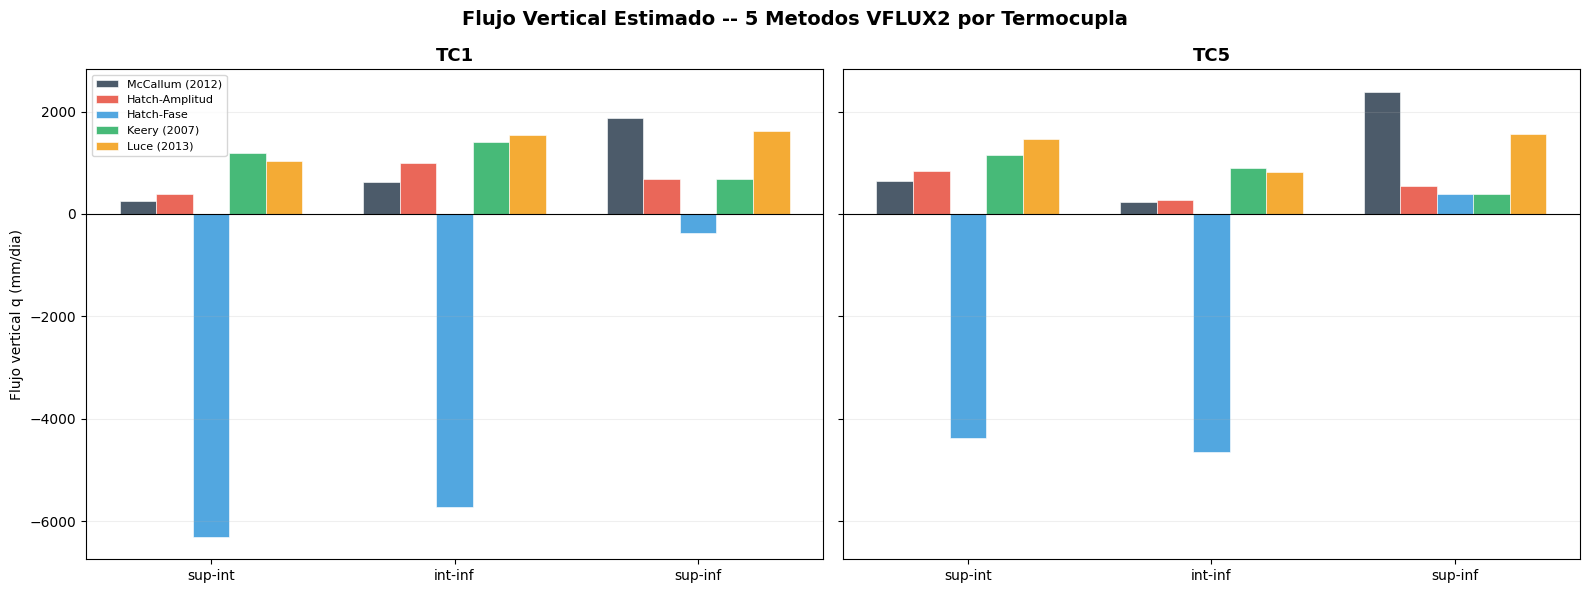

INTERPRETACION:
  Barras sobre cero: infiltracion (rio -> acuifero).
  Barras bajo cero: exfiltracion (acuifero -> rio).
  El metodo Hatch-Fase produce valores anomalos (barras grandes negativas)
  debido a la inestabilidad numerica con senal atenuada en profundidad.
  Los otros 4 metodos son consistentes e indican infiltracion en ambas TC.


In [34]:
# ============================================================================
# 11.1 FLUJOS VERTICALES POR PAR Y METODO -- GRAFICO DE BARRAS
# ============================================================================
method_colors = {
    'mccallum': '#2c3e50', 'hatch_amplitude': '#e74c3c', 'hatch_phase': '#3498db',
    'keery': '#27ae60', 'luce': '#f39c12'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax_idx, tc_name in enumerate(['TC1', 'TC5']):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    pair_names = list(tc_pairs.keys())
    x = np.arange(len(pair_names))
    width = 0.15
    
    for i, (method, name) in enumerate(zip(methods, method_names)):
        vals = [tc_pairs[p]['flux_mm_day'].get(method, 0) for p in pair_names]
        offset = (i - 2) * width
        bars = ax.bar(x + offset, vals, width, label=name, color=list(method_colors.values())[i],
                      alpha=0.85, edgecolor='white', linewidth=0.5)
    
    ax.set_xticks(x)
    short_names = [p.replace(f'{tc_name}: ', '') for p in pair_names]
    ax.set_xticklabels(short_names, fontsize=10)
    ax.set_title(f'{tc_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Flujo vertical q (mm/dia)' if ax_idx == 0 else '')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.2, axis='y')
    for spine in ax.spines.values(): spine.set_visible(True)

axes[0].legend(fontsize=8, loc='best')
plt.suptitle('Flujo Vertical Estimado -- 5 Metodos VFLUX2 por Termocupla', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'flujos_verticales_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()
print("INTERPRETACION:")
print("  Barras sobre cero: infiltracion (rio -> acuifero).")
print("  Barras bajo cero: exfiltracion (acuifero -> rio).")
print("  El metodo Hatch-Fase produce valores anomalos (barras grandes negativas)")
print("  debido a la inestabilidad numerica con senal atenuada en profundidad.")
print("  Los otros 4 metodos son consistentes e indican infiltracion en ambas TC.")

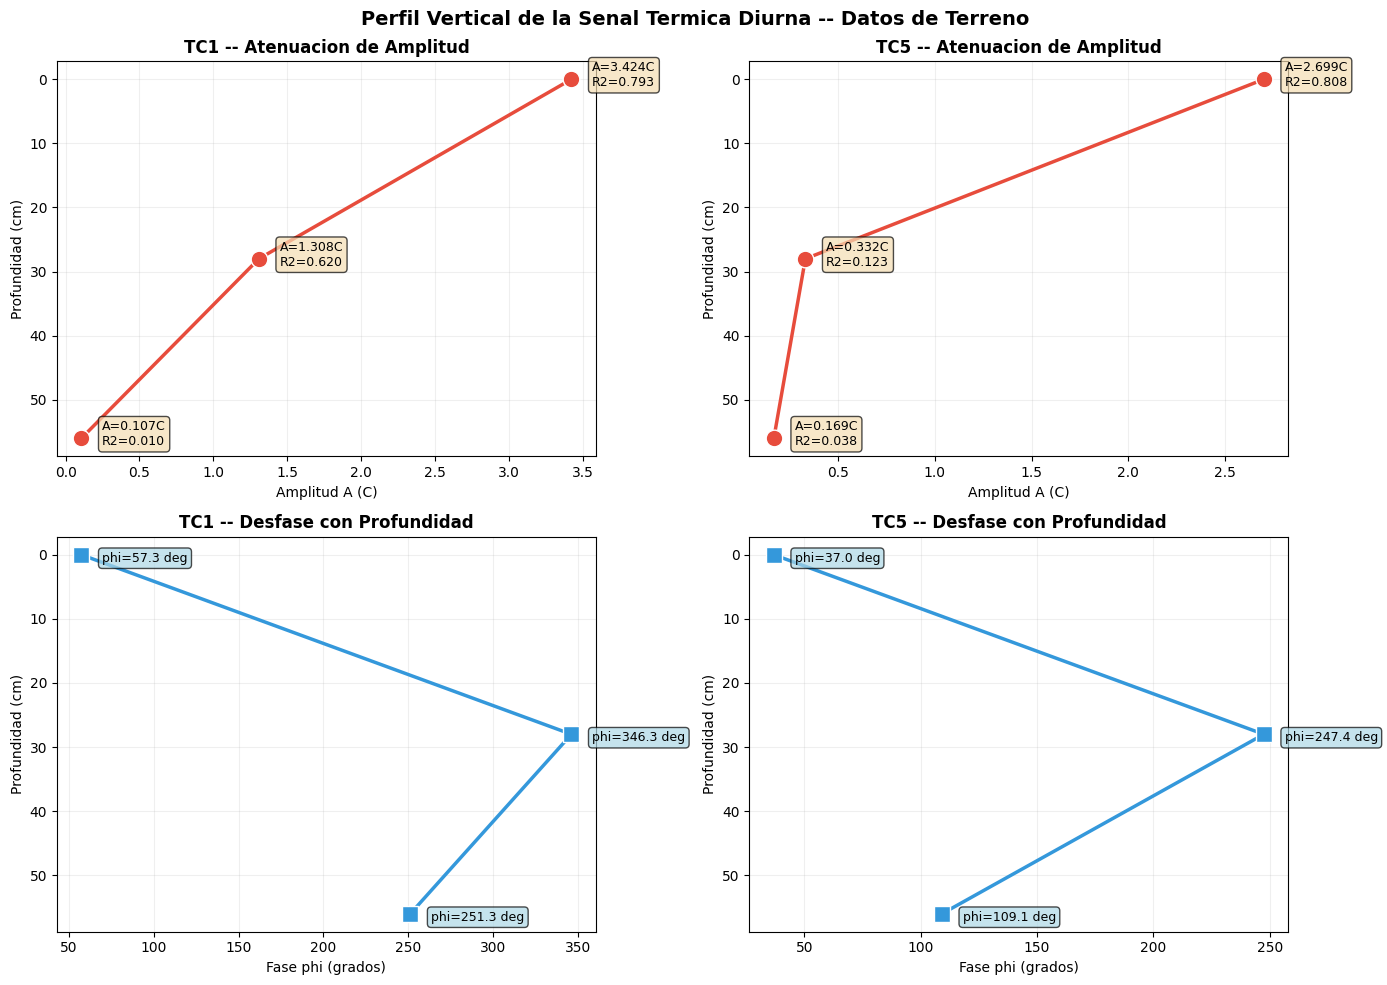

INTERPRETACION:
  Amplitud decreciente con profundidad: coherente con propagacion termica.
  El desfase aumenta con la profundidad (retraso de la senal).
  TC1 muestra una atenuacion mas gradual (3.42 -> 1.31 -> 0.11 C) que TC5
  (2.70 -> 0.33 -> 0.17 C), donde la caida es mas abrupta entre superficie
  e intermedio. Esto puede indicar diferencias en permeabilidad del lecho.


In [35]:
# ============================================================================
# 11.2 PERFIL VERTICAL DE AMPLITUD Y FASE POR TERMOCUPLA
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (tc_name, tc_map) in enumerate([('TC1', tc1), ('TC5', tc5)]):
    tc_sensors = [tc_map['surface'], tc_map['intermediate'], tc_map['deep']]
    tc_amps = [harmonic_results[s]['amplitude'] for s in tc_sensors if s in harmonic_results]
    tc_phases = [harmonic_results[s]['phase'] for s in tc_sensors if s in harmonic_results]
    tc_r2 = [harmonic_results[s]['r_squared'] for s in tc_sensors if s in harmonic_results]
    tc_d = [depths_m[s] * 100 for s in tc_sensors if s in harmonic_results]
    
    # Amplitud vs profundidad
    ax1 = axes[0][col_idx]
    ax1.plot(tc_amps, tc_d, 'o-', color='#e74c3c', markersize=12, linewidth=2.5, markeredgecolor='white')
    ax1.set_xlabel('Amplitud A (C)')
    ax1.set_ylabel('Profundidad (cm)')
    ax1.set_title(f'{tc_name} -- Atenuacion de Amplitud', fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.2)
    for a, d, r2 in zip(tc_amps, tc_d, tc_r2):
        ax1.annotate(f'A={a:.3f}C\nR2={r2:.3f}', (a, d),
                     textcoords='offset points', xytext=(15, -5), fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))
    for spine in ax1.spines.values(): spine.set_visible(True)
    
    # Fase vs profundidad
    ax2 = axes[1][col_idx]
    phases_deg = [np.degrees(p) for p in tc_phases]
    ax2.plot(phases_deg, tc_d, 's-', color='#3498db', markersize=12, linewidth=2.5, markeredgecolor='white')
    ax2.set_xlabel('Fase phi (grados)')
    ax2.set_ylabel('Profundidad (cm)')
    ax2.set_title(f'{tc_name} -- Desfase con Profundidad', fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.2)
    for p, d in zip(phases_deg, tc_d):
        ax2.annotate(f'phi={p:.1f} deg', (p, d),
                     textcoords='offset points', xytext=(15, -5), fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    for spine in ax2.spines.values(): spine.set_visible(True)

plt.suptitle('Perfil Vertical de la Senal Termica Diurna -- Datos de Terreno', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'perfil_termico_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()
print("INTERPRETACION:")
print("  Amplitud decreciente con profundidad: coherente con propagacion termica.")
print("  El desfase aumenta con la profundidad (retraso de la senal).")
print("  TC1 muestra una atenuacion mas gradual (3.42 -> 1.31 -> 0.11 C) que TC5")
print("  (2.70 -> 0.33 -> 0.17 C), donde la caida es mas abrupta entre superficie")
print("  e intermedio. Esto puede indicar diferencias en permeabilidad del lecho.")

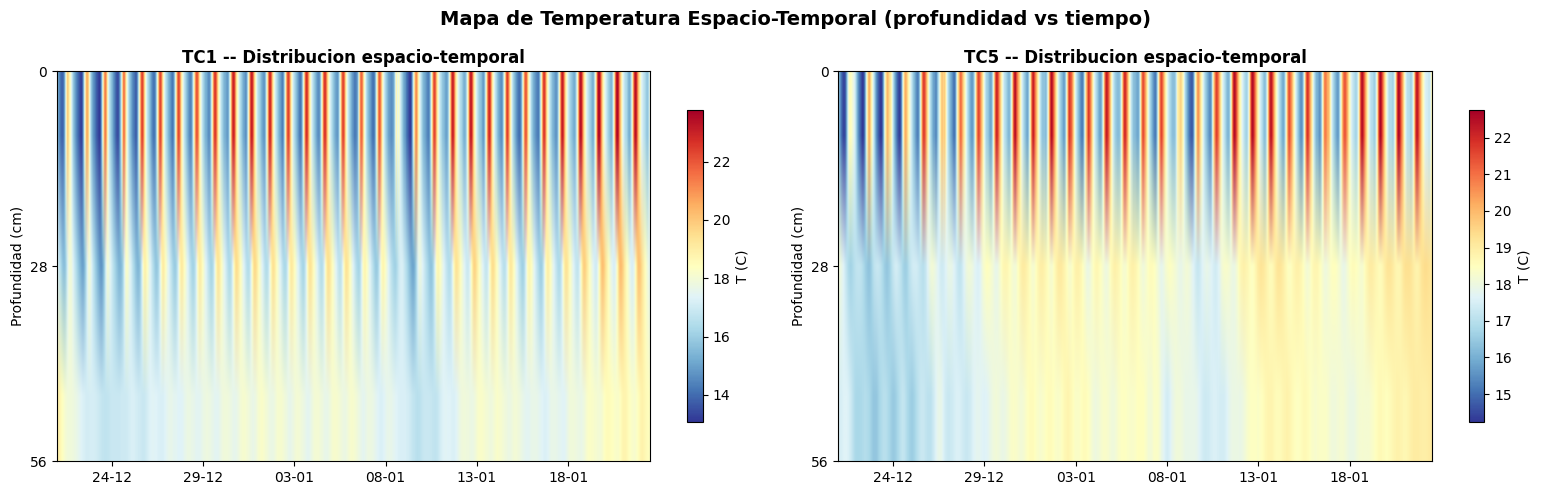

INTERPRETACION:
  Se observa la propagacion de la onda termica diurna hacia profundidad.
  Los patrones verticales rojos/azules alternantes representan los ciclos
  caliente/frio diurnos. La atenuacion rapida con profundidad es visible
  como la homogeneizacion del color hacia la base del perfil.
  TC1 muestra bandas mas definidas que TC5, consistente con la mayor
  amplitud superficial registrada en TC1.


In [36]:
# ============================================================================
# 11.3 HEATMAP ESPACIO-TEMPORAL DE TEMPERATURA
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, (tc_name, tc_map) in enumerate([('TC1', tc1), ('TC5', tc5)]):
    ax = axes[ax_idx]
    tc_sensors = [tc_map['surface'], tc_map['intermediate'], tc_map['deep']]
    tc_depths_cm = [0, 28, 56]
    
    # Construir matriz fecha x profundidad
    mask = (df_aligned['fecha'] >= cutoff_start) & (df_aligned['fecha'] <= cutoff_end)
    df_tc = df_aligned[mask].copy()
    
    temp_matrix = np.column_stack([df_tc[s].values for s in tc_sensors])
    
    # Interpolar NaN para visualizacion
    for j in range(temp_matrix.shape[1]):
        col_data = pd.Series(temp_matrix[:, j])
        temp_matrix[:, j] = col_data.interpolate(limit=4).values
    
    extent = [0, len(df_tc), 56, 0]
    im = ax.imshow(temp_matrix.T, aspect='auto', cmap='RdYlBu_r', 
                   extent=[mdates.date2num(df_tc['fecha'].iloc[0]),
                           mdates.date2num(df_tc['fecha'].iloc[-1]),
                           56, 0],
                   interpolation='bilinear')
    ax.set_ylabel('Profundidad (cm)')
    ax.set_title(f'{tc_name} -- Distribucion espacio-temporal', fontweight='bold')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    ax.set_yticks(tc_depths_cm)
    cbar = plt.colorbar(im, ax=ax, label='T (C)', shrink=0.8)
    for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Mapa de Temperatura Espacio-Temporal (profundidad vs tiempo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'heatmap_temperatura_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()
print("INTERPRETACION:")
print("  Se observa la propagacion de la onda termica diurna hacia profundidad.")
print("  Los patrones verticales rojos/azules alternantes representan los ciclos")
print("  caliente/frio diurnos. La atenuacion rapida con profundidad es visible")
print("  como la homogeneizacion del color hacia la base del perfil.")
print("  TC1 muestra bandas mas definidas que TC5, consistente con la mayor")
print("  amplitud superficial registrada en TC1.")

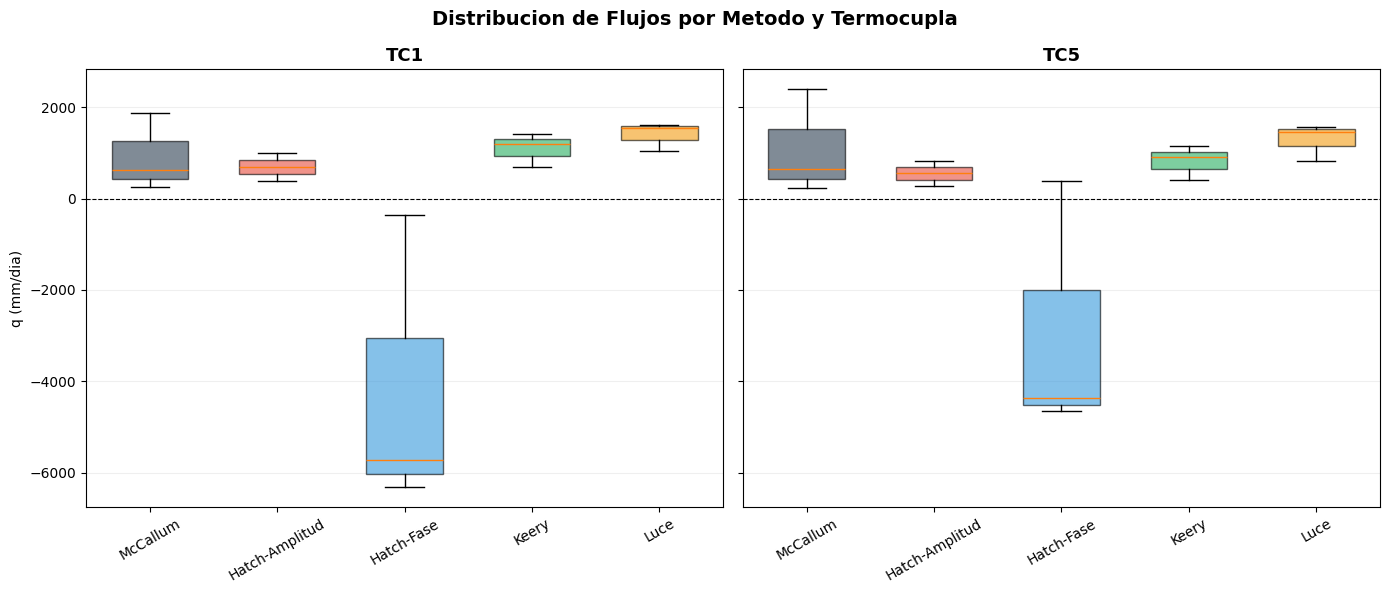

INTERPRETACION:
  La alta dispersion de Hatch-Fase confirma su inestabilidad con senal debil.
  McCallum, Keery y Luce muestran distribucion concentrada en valores positivos.
  Hatch-Amplitud presenta la menor dispersion, al depender solo del ratio
  de amplitudes que es mas robusto que la diferencia de fase.
  Todos los metodos (excepto Hatch-Fase) convergen en infiltracion neta.


In [37]:
# ============================================================================
# 11.4 COMPARACION ENTRE METODOS -- BOXPLOT
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax_idx, tc_name in enumerate(['TC1', 'TC5']):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    
    data_by_method = {}
    for method, name in zip(methods, method_names):
        vals = [v['flux_mm_day'].get(method, np.nan) for v in tc_pairs.values()]
        vals = [x for x in vals if not np.isnan(x)]
        data_by_method[name] = vals
    
    bp = ax.boxplot(data_by_method.values(), tick_labels=[n.split('(')[0].strip() for n in data_by_method.keys()],
                    patch_artist=True, widths=0.6)
    
    colors_box = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#f39c12']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'{tc_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('q (mm/dia)' if ax_idx == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.2, axis='y')
    for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Distribucion de Flujos por Metodo y Termocupla', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'boxplot_flujos_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()
print("INTERPRETACION:")
print("  La alta dispersion de Hatch-Fase confirma su inestabilidad con senal debil.")
print("  McCallum, Keery y Luce muestran distribucion concentrada en valores positivos.")
print("  Hatch-Amplitud presenta la menor dispersion, al depender solo del ratio")
print("  de amplitudes que es mas robusto que la diferencia de fase.")
print("  Todos los metodos (excepto Hatch-Fase) convergen en infiltracion neta.")

---
## 12. Conclusiones y Exportación de Resultados

In [38]:
# ============================================================================
# 12. RESUMEN EJECUTIVO Y EXPORTACION
# ============================================================================
print("=" * 90)
print(" RESUMEN EJECUTIVO -- ANALISIS DE DATOS DE TERRENO".center(90))
print("=" * 90)

print("\n CONFIGURACION DE CAMPO")
print(f"  - 2 termocuplas (TC1, TC5) x 3 sensores iButton c/u")
print(f"  - Profundidades: 0.00, 0.28, 0.56 m bajo nivel de terreno")
print(f"  - Muestreo: 30 min | Periodo: 21-Dic-2025 a 22-Ene-2026 (~33 dias)")

print("\n ANALISIS ARMONICO")
for tc_name, tc_map in [('TC1', tc1), ('TC5', tc5)]:
    for pos, pos_es in [('surface', 'Sup'), ('intermediate', 'Int'), ('deep', 'Inf')]:
        col = tc_map[pos]
        if col in harmonic_results:
            r = harmonic_results[col]
            d = depths_m[col]*100
            print(f"  - {tc_name} {pos_es} ({d:.0f}cm): A={r['amplitude']:.3f}C, phi={np.degrees(r['phase']):.1f} deg, R2={r['r_squared']:.3f}")

print("\n FLUJOS ESTIMADOS (McCallum, 2012 -- metodo recomendado)")
for pair_name, flux_result in all_flux_results.items():
    v = flux_result['flux_mm_day'].get('mccallum', np.nan)
    if not np.isnan(v):
        dir_str = 'Infiltracion' if v > 0 else 'Exfiltracion'
        print(f"  - {pair_name}: q = {v:.2f} mm/dia ({dir_str})")

print("\n" + "=" * 90)

# --- EXPORTAR RESULTADOS ---
print("\nExportando resultados...")

# 1. Tabla de flujos
df_results.to_csv(out_dir / 'flujos_todos_metodos.csv', index=False)

# 2. Estadisticas de sensores
df_stats.to_csv(out_dir / 'estadisticas_sensores.csv', index=False)

# 3. Datos alineados
df_aligned.to_csv(out_dir / 'temperaturas_alineadas.csv', index=False)

# 4. Resultados armonicos
harm_export = []
for col, r in harmonic_results.items():
    harm_export.append({
        'sensor': col,
        'tc': tc_assignment[col],
        'profundidad_m': depths_m[col],
        'amplitud_C': r['amplitude'],
        'fase_rad': r['phase'],
        'fase_deg': np.degrees(r['phase']),
        'offset_C': r['offset'],
        'R2': r['r_squared'],
    })
pd.DataFrame(harm_export).to_csv(out_dir / 'analisis_armonico.csv', index=False)

# 5. Mapeo de sensores
mapeo_export = []
for tc_name, tc_map in [('TC1', tc1), ('TC5', tc5)]:
    for pos in ['surface', 'intermediate', 'deep']:
        lbl = tc_map[pos]
        idx = int(lbl.split('_')[1]) - 1
        mapeo_export.append({
            'termocupla': tc_name,
            'posicion': pos,
            'label': lbl,
            'sensor_id': sensors[idx]['sensor_id'],
            'profundidad_m': depths_m[lbl],
        })
pd.DataFrame(mapeo_export).to_csv(out_dir / 'mapeo_sensores.csv', index=False)

print(f"\n[OK] Archivos exportados a: {out_dir.relative_to(project_root)}/")
for f in sorted(out_dir.glob('*.csv')):
    print(f"  - {f.name}")

# Lista de imagenes generadas
print(f"\n[OK] Imagenes guardadas en: {img_dir.relative_to(project_root)}/")
for f in sorted(img_dir.glob('*terreno*.png')):
    print(f"  - {f.name}")
for f in sorted(img_dir.glob('*tc*python*.png')):
    print(f"  - {f.name}")

                     RESUMEN EJECUTIVO -- ANALISIS DE DATOS DE TERRENO                    

 CONFIGURACION DE CAMPO
  - 2 termocuplas (TC1, TC5) x 3 sensores iButton c/u
  - Profundidades: 0.00, 0.28, 0.56 m bajo nivel de terreno
  - Muestreo: 30 min | Periodo: 21-Dic-2025 a 22-Ene-2026 (~33 dias)

 ANALISIS ARMONICO
  - TC1 Sup (0cm): A=3.424C, phi=57.3 deg, R2=0.793
  - TC1 Int (28cm): A=1.308C, phi=346.3 deg, R2=0.620
  - TC1 Inf (56cm): A=0.107C, phi=251.3 deg, R2=0.010
  - TC5 Sup (0cm): A=2.699C, phi=37.0 deg, R2=0.808
  - TC5 Int (28cm): A=0.332C, phi=247.4 deg, R2=0.123
  - TC5 Inf (56cm): A=0.169C, phi=109.1 deg, R2=0.038

 FLUJOS ESTIMADOS (McCallum, 2012 -- metodo recomendado)
  - TC1: sup-int: q = 246.00 mm/dia (Infiltracion)
  - TC1: int-inf: q = 624.82 mm/dia (Infiltracion)
  - TC1: sup-inf: q = 1878.12 mm/dia (Infiltracion)
  - TC5: sup-int: q = 650.63 mm/dia (Infiltracion)
  - TC5: int-inf: q = 225.00 mm/dia (Infiltracion)
  - TC5: sup-inf: q = 2390.38 mm/dia (Infiltrac